## Infer descriptive statistics from plot

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# --------------------------------------------------
# Figures setup
# --------------------------------------------------
plt.clf()   # needed otherwise sns.set_theme doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    # rc={
    #     "font.family": "serif",
    #     "font.serif": ["Palatino", "DejaVu Serif", "serif"],
    #     "figure.figsize": (5, 2),
    # },
)

<Figure size 640x480 with 0 Axes>

In [3]:
from ministats.utils import savefigure

In [ ]:
# Data 1

count    24.000000
mean      6.583333
std       2.465707
min       1.000000
25%       5.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: y, dtype: float64
Saved figure to figures/statsprobsfigs/descr-stats/descr_stats_from_boxplot.pdf
Saved figure to figures/statsprobsfigs/descr-stats/descr_stats_from_boxplot.png


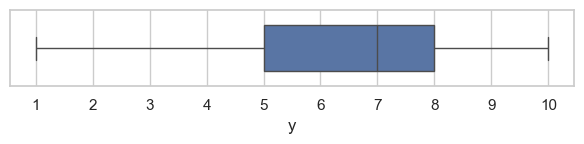

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 24 data points with roughly the requested five-number summary
ys = pd.Series([
    1, 2, 3, 4,
    5, 5, 5, 5, 6, 6,
    7, 7, 7, 7,
    8, 8, 8, 8, 8, 9,
    9, 10, 10, 10
], name="y")

print(ys.describe())

# Boxplot
fig, ax = plt.subplots(figsize=(6, 1.6))
sns.boxplot(x=ys, ax=ax, width=0.6)

# xticks at every unit
ax.set_xticks(range(1, 11, 1))

ax.set_xlabel("y")

# fig.tight_layout()
savefigure(fig, "figures/statsprobsfigs/descr-stats/descr_stats_from_boxplot.pdf")

### Data 2

In [4]:
# --------------------------------------------------
# Smooth-looking dataset with exact round summaries
# --------------------------------------------------
x = [
    30.0,
    32.09217030,
    34.00818612,
    34.85018463,
    36.39152660,
    36.52449362,
    38.23778766,
    39.47663788,
    41.04205981,
    42.0,
    42.0,
    42.18110027,
    42.90548993,
    42.97166299,
    43.40885287,
    43.54876321,
    45.77040453,
    46.38451889,
    48.42161285,
    49.0,
    51.0,
    51.38397591,
    51.46912866,
    52.13781382,
    52.60077892,
    52.81724930,
    53.67718024,
    53.77612886,
    56.85494198,
    58.0,
    58.0,
    58.43604592,
    59.19097326,
    59.20685403,
    59.71104649,
    60.24636494,
    60.79210028,
    62.33123180,
    67.15273345,
    70.0,
]

df = pd.DataFrame({"x": x})
s = df["x"]

In [5]:
# --------------------------------------------------
# Descriptive statistics
# --------------------------------------------------
mean_x = s.mean()
std_x = s.std(ddof=1)      # sample standard deviation
q1 = s.quantile(0.25)
q2 = s.quantile(0.50)
q3 = s.quantile(0.75)
iqr = q3 - q1
xmin = s.min()
xmax = s.max()

print(f"n    = {len(s)}")
print(f"mean = {mean_x}")
print(f"std  = {std_x}")
print(f"Q1   = {q1}")
print(f"Q2   = {q2}")
print(f"Q3   = {q3}")
print(f"IQR  = {iqr}")
print(f"min  = {xmin}")
print(f"max  = {xmax}")

# sanity checks
assert np.isclose(mean_x, 49)
assert np.isclose(std_x, 10)
assert np.isclose(q1, 42)
assert np.isclose(q2, 50)
assert np.isclose(q3, 58)
assert np.isclose(iqr, 16)
assert np.isclose(xmin, 30)
assert np.isclose(xmax, 70)

n    = 40
mean = 49.00000000050001
std  = 10.000000000110077
Q1   = 42.0
Q2   = 50.0
Q3   = 58.0
IQR  = 16.0
min  = 30.0
max  = 70.0


Saved figure to figures/statsprobsfigs/descr-stats/descr_stats_from_plots.pdf
Saved figure to figures/statsprobsfigs/descr-stats/descr_stats_from_plots.png


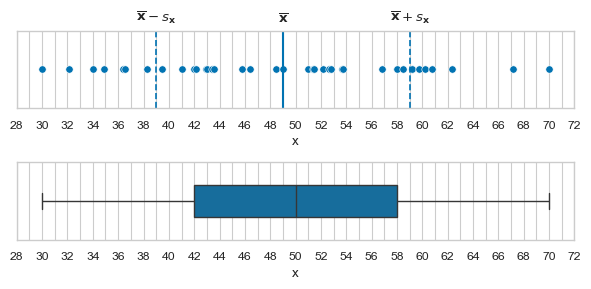

In [13]:
# --------------------------------------------------
# Common x-axis ticks
# --------------------------------------------------
xticks = range(28, 73, 1)
xticklabels = [str(t) if t % 2 == 0 else "" for t in xticks]


# In a notebook:
# %config InlineBackend.figure_format = 'retina'

# ==================================================
# 1) Scatter plot
# ==================================================
fig, axs = plt.subplots(2, 1, figsize=(6, 3))

y = np.zeros(len(df))
ax = sns.scatterplot(x=df["x"], y=y, s=28, ax=axs[0])

# Reference lines
ax.axvline(mean_x, linestyle="-", linewidth=1.5)
ax.axvline(mean_x - std_x, linestyle="--", linewidth=1.2)
ax.axvline(mean_x + std_x, linestyle="--", linewidth=1.2)

# ax.set_title("Scatter plot")
ax.set_xlabel("x")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_ylim(-0.06, 0.06)

ax.set_xlim(28, 72)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

# Put labels above the axes, not inside the plotting region
trans = ax.get_xaxis_transform()   # x in data coords, y in axes coords
ax.text(mean_x, 1.06, r"$\overline{\mathbf{x}}$",
        transform=trans, ha="center", va="bottom", clip_on=False)
ax.text(mean_x - std_x, 1.06, r"$\overline{\mathbf{x}} - s_{\mathbf{x}}$",
        transform=trans, ha="center", va="bottom", clip_on=False)
ax.text(mean_x + std_x, 1.06, r"$\overline{\mathbf{x}} + s_{\mathbf{x}}$",
        transform=trans, ha="center", va="bottom", clip_on=False)

# sns.despine(left=True)

# # leave extra room above for the labels
# # fig.tight_layout(pad=0.6)
# # fig.subplots_adjust(top=0.78)
# # plt.show()


# ==================================================
# 2) Box plot
# ==================================================

ax = sns.boxplot(
    x=s,
    orient="h",
    whis=1.2,
    width=0.4,
    ax=axs[1]
)


# ax.set_title("Box plot")
ax.set_xlabel("x")
ax.set_ylabel("")
ax.set_yticks([])

ax.set_xlim(28, 72)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

# fig.tight_layout()
savefigure(fig, "figures/statsprobsfigs/descr-stats/descr_stats_from_plots.pdf")